# DINOv2 Feature Analysis
Same analysis as `analyze_features.ipynb` but using DINOv2 (frozen `dinov2_vits14`) features instead of Dreamer4 tokenizer latents.

DINOv2 encoding adapted from `dino_wm/models/dino.py`.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.io import read_image
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = "/Project/world_model/dreamer4/data/expert"
TASK = "pendulum-spin"  # change to any task in data/expert/
N_FRAMES = 40            # number of frames to analyze (None = all)
FEATURE_MODE = "cls"     # "cls" = CLS token (384-d), "patch_mean" = mean-pooled patch tokens (384-d)

# Load DINOv2 vits14 (same model as dino_wm/models/dino.py)
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dino = dino.to(device).eval()
print(f"DINOv2 loaded: emb_dim={dino.num_features}, patch_size={dino.patch_size}")

# Preprocessing (from dino_wm/datasets/img_transforms.py)
# Input to DINOv2: 196x196 so patches align to 14x14 grid
dino_transform = transforms.Compose([
    transforms.Resize(196),
    transforms.CenterCrop(196),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

Using device: cuda


Using cache found in /home/robin/.cache/torch/hub/facebookresearch_dinov2_main
/home/robin/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/robin/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/robin/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded: emb_dim=384, patch_size=14


Loaded 10020 frames, shape: torch.Size([10020, 3, 224, 224])


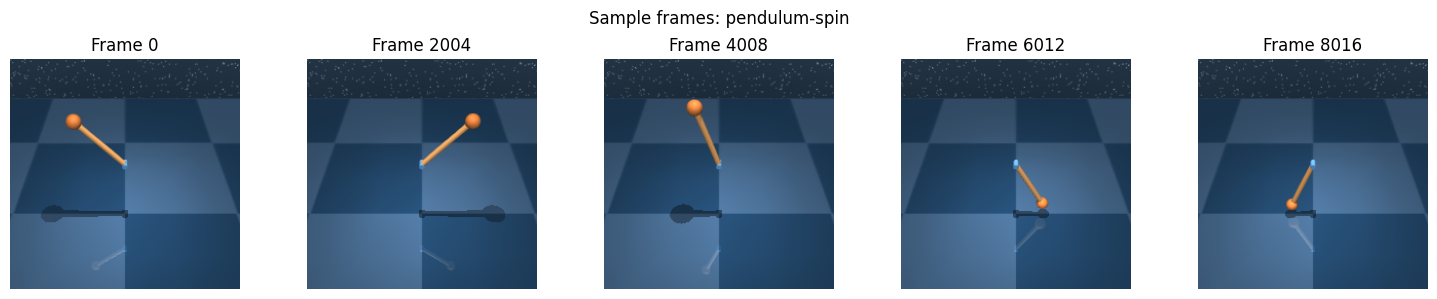

In [2]:
# Cell 2: Load raw frames from expert PNG filmstrips

def load_expert_frames(task: str, data_dir: str, target_size: int = 224):
    """Load all frames for a task from PNG filmstrips.
    Returns (N, 3, H, W) float tensor in [0,1]."""
    frames_list = []
    i = 0
    while True:
        path = os.path.join(data_dir, f"{task}-{i}.png")
        if not os.path.exists(path):
            break
        img = read_image(path)  # (3, 224, W_total) uint8
        c, h, w_total = img.shape
        assert h == 224 and w_total % 224 == 0, f"Unexpected shape {img.shape}"
        n_frames = w_total // 224
        frames = img.view(c, 224, n_frames, 224).permute(2, 0, 1, 3)
        frames_list.append(frames)
        i += 1
    all_frames = torch.cat(frames_list, 0)  # (total_N, 3, 224, 224)
    # Resize to target size
    all_frames = F.interpolate(
        all_frames.float() / 255.0,
        size=(target_size, target_size),
        mode="bilinear", align_corners=False,
    )
    return all_frames

frames = load_expert_frames(TASK, DATA_DIR, target_size=224)
print(f"Loaded {frames.shape[0]} frames, shape: {frames.shape}")

# Show a few sample frames
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = i * (len(frames) // 5)
    ax.imshow(frames[idx].permute(1, 2, 0).numpy())
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.suptitle(f"Sample frames: {TASK}")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Load metadata, identify episode boundaries, trim to N_FRAMES

meta = torch.load(os.path.join(DATA_DIR, f"{TASK}.pt"), weights_only=False)
episodes = meta["episode"]   # (N,) int64
actions = meta["action"]     # (N, A) float32
rewards = meta["reward"]     # (N,) float32

print(f"Full dataset: {episodes.shape[0]} timesteps, {episodes.unique().shape[0]} episodes")

# Trim to first N_FRAMES
if N_FRAMES is not None and N_FRAMES < len(frames):
    frames = frames[:N_FRAMES]
    episodes = episodes[:N_FRAMES]
    actions = actions[:N_FRAMES]
    rewards = rewards[:N_FRAMES]
    print(f"Trimmed to first {N_FRAMES} frames")

assert frames.shape[0] == episodes.shape[0]

# Find episode boundaries within the trimmed range
unique_eps = episodes.unique(sorted=True)
ep_boundaries = []
for ep_id in unique_eps:
    mask = episodes == ep_id
    indices = mask.nonzero(as_tuple=True)[0]
    ep_boundaries.append((indices[0].item(), indices[-1].item() + 1))

print(f"Analyzing: {frames.shape[0]} frames, {len(ep_boundaries)} episodes")
print(f"Episode lengths: {[e-s for s, e in ep_boundaries]}")

Full dataset: 10020 timesteps, 20 episodes
Trimmed to first 40 frames
Analyzing: 40 frames, 1 episodes
Episode lengths: [40]


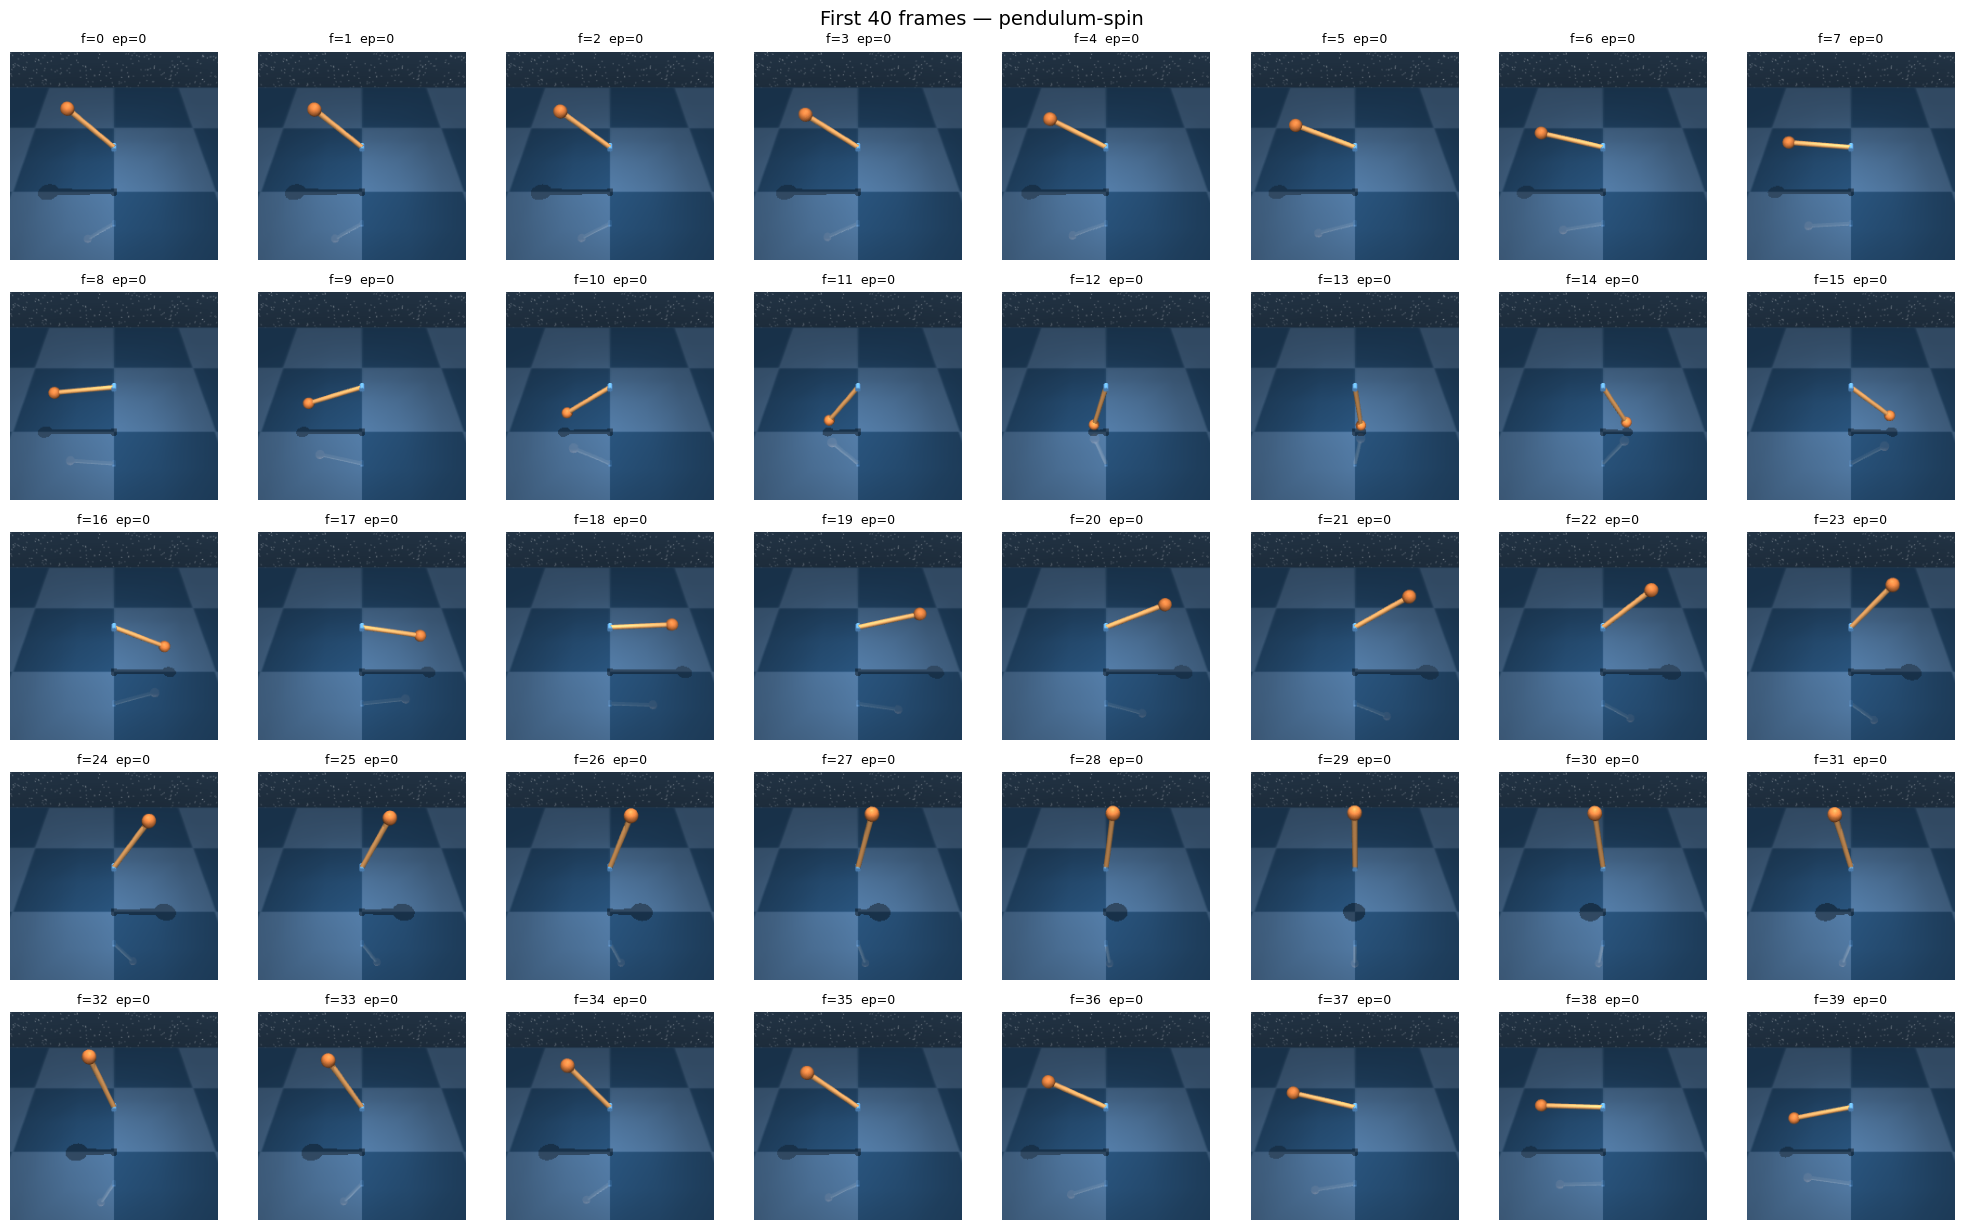

In [4]:
# Cell 3b: Quick-check first N frames

N_PREVIEW = 40
ncols = min(N_PREVIEW, 8)
nrows = (N_PREVIEW + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows))
axes = np.atleast_2d(axes)
for i in range(nrows * ncols):
    r, c = divmod(i, ncols)
    if i < N_PREVIEW:
        axes[r, c].imshow(frames[i].permute(1, 2, 0).clamp(0, 1).numpy())
        ep_id = episodes[i].item()
        axes[r, c].set_title(f"f={i}  ep={ep_id}", fontsize=9)
    axes[r, c].axis("off")
plt.suptitle(f"First {N_PREVIEW} frames \u2014 {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Cell 4: Encode all frames with DINOv2

@torch.inference_mode()
def encode_frames_dino(model, frames, transform, device, feature_mode="cls", batch_size=32):
    """Encode (N,3,H,W) frames -> (N, emb_dim) DINOv2 features."""
    all_feats = []
    for i in range(0, len(frames), batch_size):
        batch = transform(frames[i:i+batch_size]).to(device)
        out = model.forward_features(batch)
        if feature_mode == "cls":
            feat = out["x_norm_clstoken"]            # (B, 384)
        else:  # patch_mean
            feat = out["x_norm_patchtokens"].mean(1)  # (B, 384)
        all_feats.append(feat.cpu())
    return torch.cat(all_feats, 0)

latents = encode_frames_dino(dino, frames, dino_transform, device, FEATURE_MODE)
print(f"DINOv2 feature shape: {latents.shape}")  # (N, 384)

features = latents.numpy()
print(f"Feature range: [{features.min():.3f}, {features.max():.3f}]")

DINOv2 feature shape: torch.Size([40, 384])
Feature range: [-8.495, 8.083]


**Note:** DINOv2 is encoder-only — no reconstruction cell (unlike the Dreamer4 tokenizer notebook).

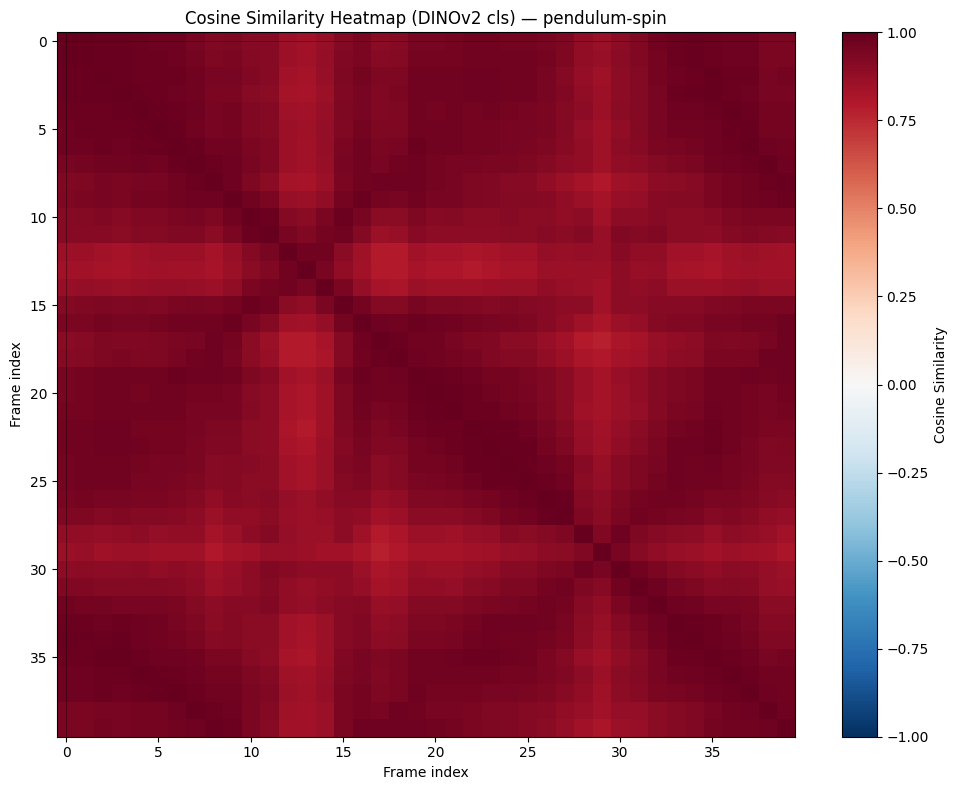

In [6]:
# Cell 6: Cosine similarity heatmap

feat_t = torch.from_numpy(features)  # (N, 384)
feat_norm = feat_t / feat_t.norm(dim=1, keepdim=True).clamp(min=1e-8)
cos_sim = (feat_norm @ feat_norm.T).numpy()  # (N, N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cos_sim, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Cosine Similarity")

for start, end in ep_boundaries:
    ax.axhline(y=start, color="black", linewidth=0.5, alpha=0.5)
    ax.axvline(x=start, color="black", linewidth=0.5, alpha=0.5)

ax.set_xlabel("Frame index")
ax.set_ylabel("Frame index")
ax.set_title(f"Cosine Similarity Heatmap (DINOv2 {FEATURE_MODE}) \u2014 {TASK}")
plt.tight_layout()
plt.show()

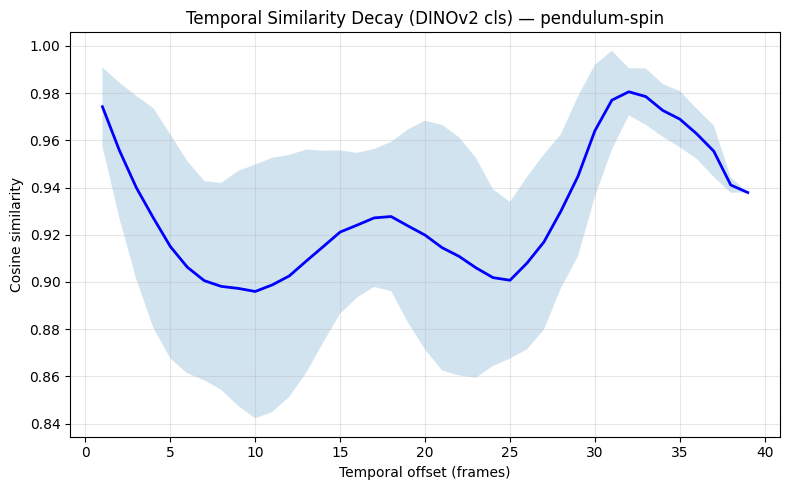

In [7]:
# Cell 7: Temporal similarity decay curve

max_offset = 100
sim_by_offset = {k: [] for k in range(1, max_offset + 1)}

for start, end in ep_boundaries:
    ep_feat = feat_norm[start:end]
    L = ep_feat.shape[0]
    for k in range(1, min(max_offset + 1, L)):
        sims = (ep_feat[:-k] * ep_feat[k:]).sum(dim=1)
        sim_by_offset[k].extend(sims.tolist())

offsets = list(range(1, max_offset + 1))
mean_sims = [np.mean(sim_by_offset[k]) for k in offsets if sim_by_offset[k]]
std_sims = [np.std(sim_by_offset[k]) for k in offsets if sim_by_offset[k]]
offsets = offsets[:len(mean_sims)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(offsets, mean_sims, "b-", linewidth=2)
ax.fill_between(offsets,
                np.array(mean_sims) - np.array(std_sims),
                np.array(mean_sims) + np.array(std_sims),
                alpha=0.2)
ax.set_xlabel("Temporal offset (frames)")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"Temporal Similarity Decay (DINOv2 {FEATURE_MODE}) \u2014 {TASK}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

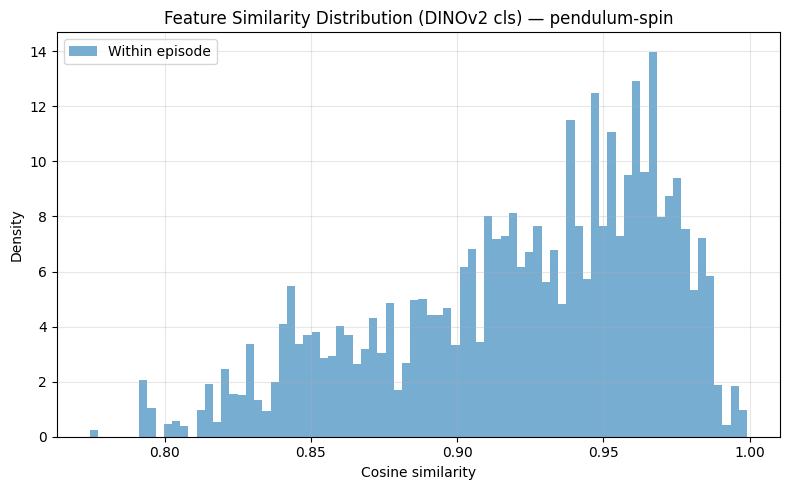

Within-episode:  mean=0.922, std=0.047


In [8]:
# Cell 8: Within-episode vs across-episode similarity distributions

n_samples = 10000
rng = np.random.default_rng(42)

within_sims = []
across_sims = []

for _ in range(n_samples):
    ep_idx = rng.integers(len(ep_boundaries))
    s, e = ep_boundaries[ep_idx]
    if e - s < 2:
        continue
    i, j = rng.choice(e - s, size=2, replace=False) + s
    within_sims.append(cos_sim[i, j])

if len(ep_boundaries) >= 2:
    for _ in range(n_samples):
        ep1, ep2 = rng.choice(len(ep_boundaries), size=2, replace=False)
        s1, e1 = ep_boundaries[ep1]
        s2, e2 = ep_boundaries[ep2]
        i = rng.integers(s1, e1)
        j = rng.integers(s2, e2)
        across_sims.append(cos_sim[i, j])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(within_sims, bins=80, alpha=0.6, density=True, label="Within episode")
if across_sims:
    ax.hist(across_sims, bins=80, alpha=0.6, density=True, label="Across episodes")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title(f"Feature Similarity Distribution (DINOv2 {FEATURE_MODE}) \u2014 {TASK}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Within-episode:  mean={np.mean(within_sims):.3f}, std={np.std(within_sims):.3f}")
if across_sims:
    print(f"Across-episode:  mean={np.mean(across_sims):.3f}, std={np.std(across_sims):.3f}")

In [9]:
# Cell 9: PCA -> t-SNE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

n_samples, n_feat = features.shape
if n_feat > n_samples:
    n_pca = max(2, n_samples - 1)
    pca_input = PCA(n_components=n_pca).fit_transform(features)
    print(f"PCA reduced: {features.shape} -> {pca_input.shape} (N < feat_dim)")
elif n_feat > 50:
    pca_input = PCA(n_components=50).fit_transform(features)
    print(f"PCA reduced: {features.shape} -> {pca_input.shape}")
else:
    pca_input = features
    print(f"Skipping PCA (feat_dim={n_feat} already small)")

perp = min(30, max(2, n_samples // 4))
tsne = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate="auto",
    init="random" if pca_input.shape[1] < 2 else "pca",
    max_iter=2000,
    metric="euclidean",
    random_state=0,
    verbose=1,
)
Y = tsne.fit_transform(pca_input)
print(f"t-SNE done: {Y.shape} (perplexity={perp})")

PCA reduced: (40, 384) -> (40, 39) (N < feat_dim)
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 40 samples in 0.000s...
[t-SNE] Computed neighbors for 40 samples in 0.090s...
[t-SNE] Computed conditional probabilities for sample 40 / 40
[t-SNE] Mean sigma: 6.796391
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.890274
[t-SNE] KL divergence after 1400 iterations: 0.134748
t-SNE done: (40, 2) (perplexity=10)


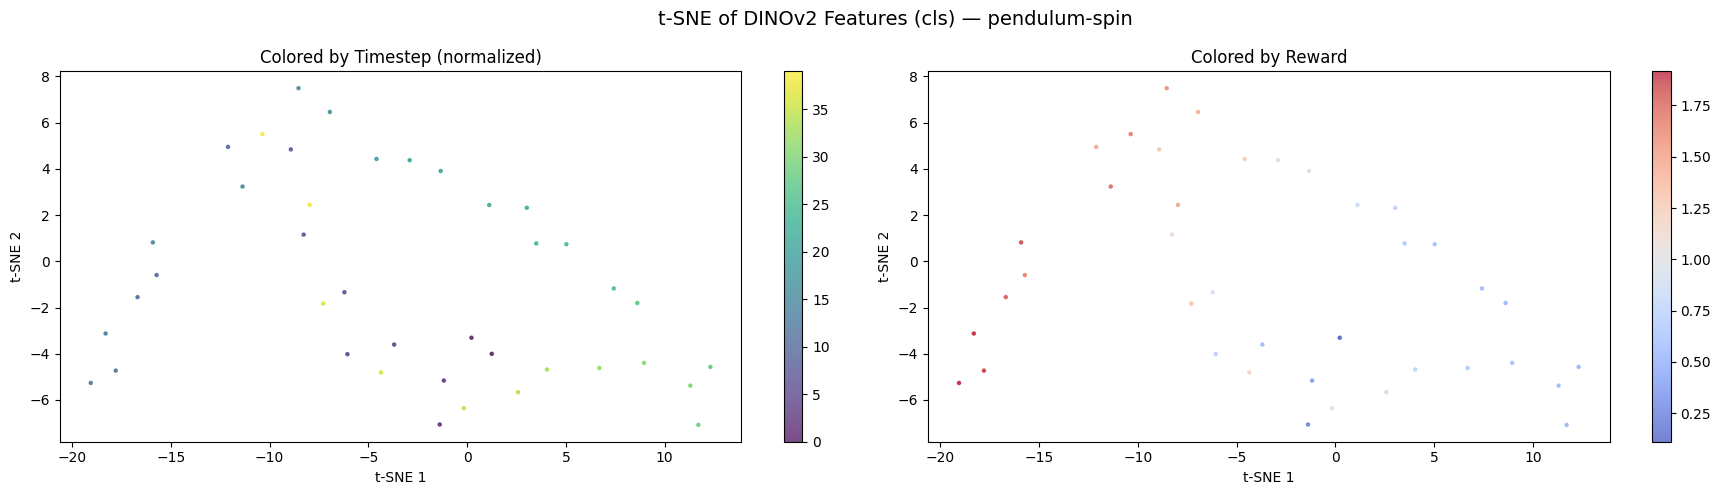

In [10]:
# Cell 10: t-SNE scatter plots

pt_size = max(3, 200 // max(len(features), 1))
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# # Color by episode
# ep_ids = episodes.cpu().numpy()
# sc0 = axes[0].scatter(Y[:, 0], Y[:, 1], c=ep_ids, cmap="tab20", s=pt_size, alpha=0.7, rasterized=True)
# axes[0].set_title("Colored by Episode")
# plt.colorbar(sc0, ax=axes[0])

# Color by timestep within episode
timesteps = np.zeros(len(features))
for start, end in ep_boundaries:
    ep_len = end - start
    timesteps[start:end] = np.arange(ep_len) #/ max(ep_len - 1, 1)
sc1 = axes[0].scatter(Y[:, 0], Y[:, 1], c=timesteps, cmap="viridis", s=pt_size, alpha=0.7, rasterized=True)
axes[0].set_title("Colored by Timestep (normalized)")
plt.colorbar(sc1, ax=axes[0])

# Color by reward
rew_np = rewards.cpu().numpy()
sc2 = axes[1].scatter(Y[:, 0], Y[:, 1], c=rew_np, cmap="coolwarm", s=pt_size, alpha=0.7, rasterized=True)
axes[1].set_title("Colored by Reward")
plt.colorbar(sc2, ax=axes[1])

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle(f"t-SNE of DINOv2 Features ({FEATURE_MODE}) \u2014 {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

NN scores (k=20): mean=207.7237, std=118.6887
Min (densest): 103.3097, Max (most isolated): 534.5356


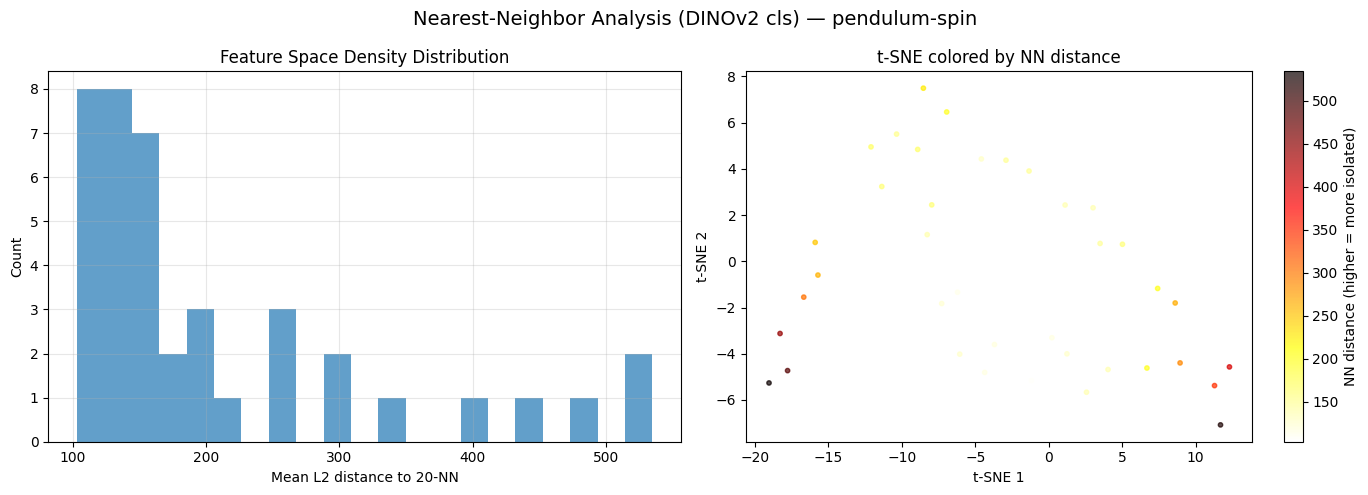

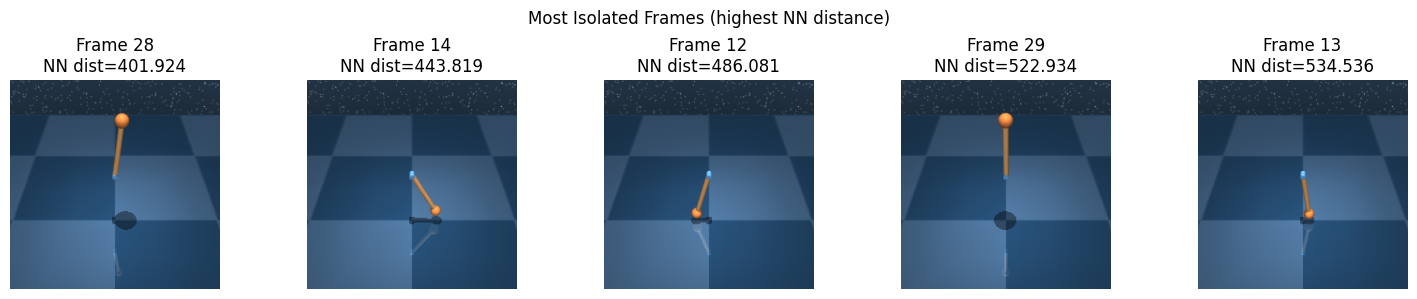

In [11]:
# Cell 11: FAISS nearest-neighbor analysis

import faiss

features_f32 = features.astype(np.float32)
index = faiss.IndexFlatL2(features_f32.shape[1])
index.add(features_f32)

k_nn = min(20, len(features_f32) - 1)
distances, nn_indices = index.search(features_f32, k_nn)
nn_scores = distances.mean(axis=-1)

print(f"NN scores (k={k_nn}): mean={nn_scores.mean():.4f}, std={nn_scores.std():.4f}")
print(f"Min (densest): {nn_scores.min():.4f}, Max (most isolated): {nn_scores.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(nn_scores, bins=min(80, len(nn_scores) // 2 + 1), alpha=0.7)
axes[0].set_xlabel(f"Mean L2 distance to {k_nn}-NN")
axes[0].set_ylabel("Count")
axes[0].set_title("Feature Space Density Distribution")
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(Y[:, 0], Y[:, 1], c=nn_scores, cmap="hot_r", s=10, alpha=0.7, rasterized=True)
plt.colorbar(sc, ax=axes[1], label="NN distance (higher = more isolated)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE colored by NN distance")

plt.suptitle(f"Nearest-Neighbor Analysis (DINOv2 {FEATURE_MODE}) \u2014 {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

# Show most isolated frames
n_outliers = min(5, len(frames))
top_outliers = np.argsort(nn_scores)[-n_outliers:]
fig, axes_out = plt.subplots(1, n_outliers, figsize=(3 * n_outliers, 3))
if n_outliers == 1:
    axes_out = [axes_out]
for i, idx in enumerate(top_outliers):
    axes_out[i].imshow(frames[idx].permute(1, 2, 0).clamp(0, 1).numpy())
    axes_out[i].set_title(f"Frame {idx}\nNN dist={nn_scores[idx]:.3f}")
    axes_out[i].axis("off")
plt.suptitle("Most Isolated Frames (highest NN distance)")
plt.tight_layout()
plt.show()